# BRISQUE step by step in Google Colab

This notebook allows you to upload an image from your computer and follow the complete BRISQUE workflow:

1. Upload and display the input image.
2. Convert the image to luminance/grayscale.
3. Compute MSCN coefficients.
4. Visualize the local mean, local standard deviation, and MSCN map.
5. Fit a Generalized Gaussian Distribution (GGD) to the MSCN coefficients.
6. Compute pairwise products in four orientations: horizontal, vertical, main diagonal, and secondary diagonal.
7. Fit AGGD-based statistical features to the pairwise products.
8. Repeat the feature extraction at two image scales.
9. Build the 36-dimensional BRISQUE feature vector.
10. Compute the final BRISQUE score using OpenCV's pretrained BRISQUE model.

**Interpretation of the BRISQUE score:** lower values usually indicate better perceptual image quality, while higher values indicate stronger perceptual degradation.

In [1]:
# ============================================================
# 1. Install and import required libraries
# ============================================================

!pip -q install opencv-contrib-python-headless scipy scikit-image pandas matplotlib

import os
import cv2
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import convolve
from scipy.special import gamma
from google.colab import files
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("OpenCV version:", cv2.__version__)
print("Quality module available:", hasattr(cv2, "quality"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 8.0 MB/s eta 0:00:00
OpenCV version: 4.13.0
Quality module available: True


## 2. Upload an image from your computer

Run the following cell and select one image from your PC.

Saving original.jpg to original.jpg
Uploaded image: original.jpg


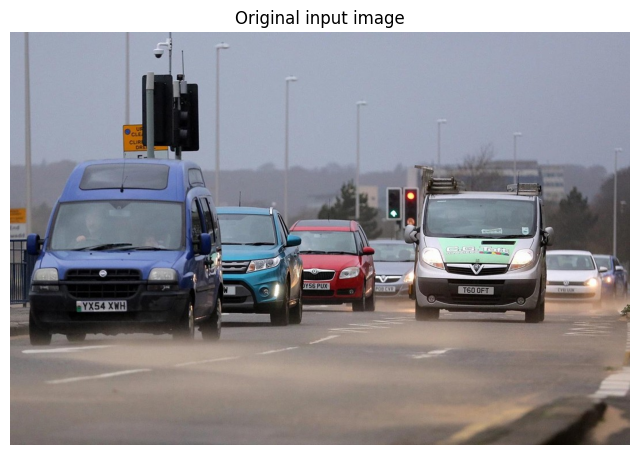

Image shape: (720, 1080, 3)


In [2]:
# ============================================================
# 2. Upload image from PC
# ============================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("The image could not be read. Please upload a valid image file.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original input image")
plt.axis("off")
plt.show()

print("Image shape:", img_rgb.shape)

## 3. Convert the image to luminance/grayscale

BRISQUE works with luminance information. Therefore, the color image is converted to grayscale.

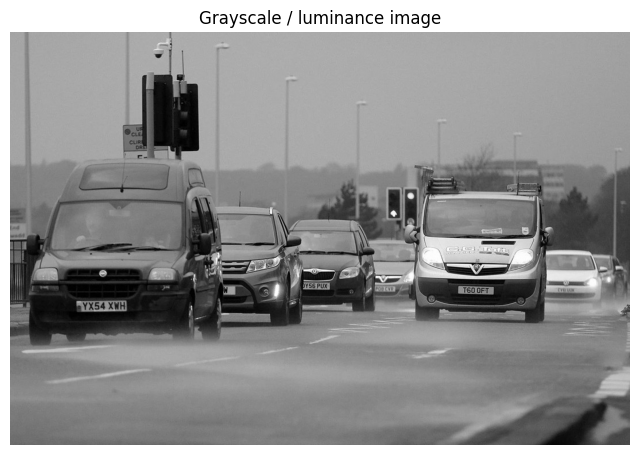

Grayscale image size: (720, 1080)


In [3]:
# ============================================================
# 3. Convert to grayscale/luminance
# ============================================================

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale / luminance image")
plt.axis("off")
plt.show()

print("Grayscale image size:", gray.shape)

## 4. Compute MSCN coefficients

The MSCN coefficient is computed as:

\[
\hat{I}(i,j)=\frac{I(i,j)-\mu(i,j)}{\sigma(i,j)+C}
\]

where:

- \(I(i,j)\) is the luminance value at pixel location \((i,j)\).
- \(\mu(i,j)\) is the local mean.
- \(\sigma(i,j)\) is the local standard deviation.
- \(C\) avoids division by zero when the local standard deviation is close to zero.

This step normalizes local luminance and contrast variations.

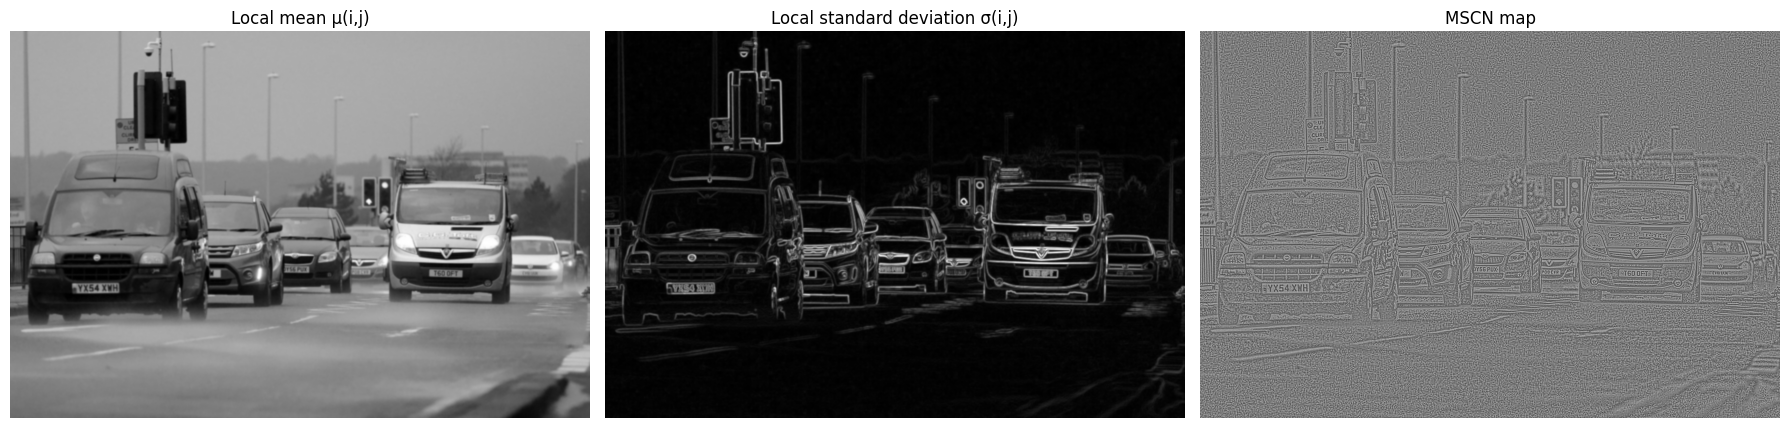

MSCN statistics:
Mean: -9.778530208219339e-05
Standard deviation: 0.4551830350042191
Minimum: -1.9870103323742883
Maximum: 2.105362683100672


In [4]:
# ============================================================
# 4. Functions to compute MSCN coefficients
# ============================================================

def gaussian_kernel_2d(size=7, sigma=7/6):
    # Creates a 2D Gaussian kernel similar to the one used in NSS-based IQA methods.
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

def compute_mscn_coefficients(image, C=1.0, kernel_size=7, sigma=7/6):
    # Computes MSCN coefficients:
    # I_hat(i,j) = [I(i,j) - mu(i,j)] / [sigma(i,j) + C]
    image = image.astype(np.float64)
    kernel = gaussian_kernel_2d(kernel_size, sigma)

    local_mean = convolve(image, kernel, mode="reflect")
    local_var = convolve(image**2, kernel, mode="reflect") - local_mean**2
    local_var = np.maximum(local_var, 0)
    local_std = np.sqrt(local_var)

    mscn = (image - local_mean) / (local_std + C)
    return mscn, local_mean, local_std

mscn, local_mean, local_std = compute_mscn_coefficients(gray)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(local_mean, cmap="gray")
axs[0].set_title("Local mean μ(i,j)")
axs[0].axis("off")

axs[1].imshow(local_std, cmap="gray")
axs[1].set_title("Local standard deviation σ(i,j)")
axs[1].axis("off")

axs[2].imshow(mscn, cmap="gray")
axs[2].set_title("MSCN map")
axs[2].axis("off")

plt.tight_layout()
plt.show()

print("MSCN statistics:")
print("Mean:", np.mean(mscn))
print("Standard deviation:", np.std(mscn))
print("Minimum:", np.min(mscn))
print("Maximum:", np.max(mscn))

## 5. Fit a Generalized Gaussian Distribution (GGD)

BRISQUE models the distribution of MSCN coefficients using a Generalized Gaussian Distribution:

\[
f(x;\alpha,\sigma^2)=\frac{\alpha}{2\beta\Gamma(1/\alpha)}
\exp\left[-\left(\frac{|x|}{\beta}\right)^\alpha\right]
\]

The two main features extracted from the MSCN coefficients are:

- \(\alpha\): shape parameter.
- \(\sigma^2\): variance of the MSCN coefficients.

GGD parameters from MSCN coefficients:
alpha = 2.028000000000002
sigma^2 = 0.20719160491761757


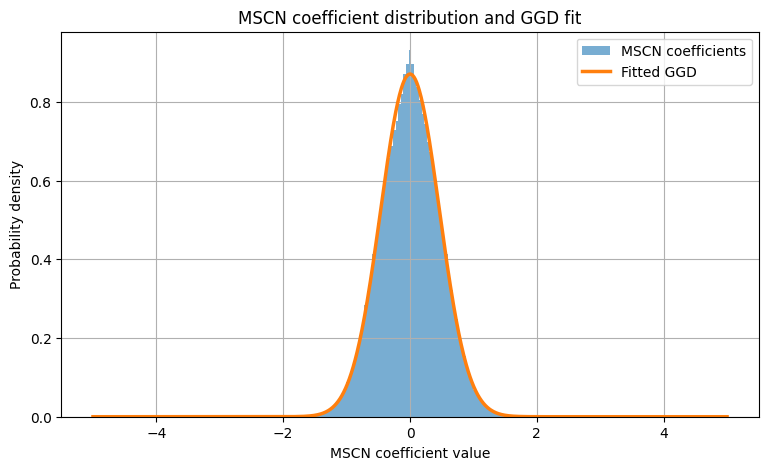

In [5]:
# ============================================================
# 5. Estimate GGD parameters
# ============================================================

def estimate_ggd_parameters(vec):
    # Estimates the GGD shape parameter alpha and variance sigma^2 using moment matching.
    vec = vec.flatten()
    vec = vec[np.isfinite(vec)]

    gammas = np.arange(0.2, 10, 0.001)
    r_gam = (gamma(2/gammas) ** 2) / (gamma(1/gammas) * gamma(3/gammas))

    sigma_sq = np.mean(vec ** 2)
    E = np.mean(np.abs(vec))
    rho = (E ** 2) / sigma_sq

    alpha = gammas[np.argmin(np.abs(r_gam - rho))]
    return alpha, sigma_sq

def ggd_pdf(x, alpha, sigma_sq):
    # Computes GGD PDF using alpha and sigma^2.
    sigma = np.sqrt(sigma_sq)
    beta = sigma * np.sqrt(gamma(1/alpha) / gamma(3/alpha))
    return (alpha / (2 * beta * gamma(1/alpha))) * np.exp(-((np.abs(x) / beta) ** alpha))

alpha_mscn, sigma_sq_mscn = estimate_ggd_parameters(mscn)
print("GGD parameters from MSCN coefficients:")
print("alpha =", alpha_mscn)
print("sigma^2 =", sigma_sq_mscn)

coeff = mscn.flatten()
coeff = coeff[np.isfinite(coeff)]
coeff_plot = coeff[(coeff > -5) & (coeff < 5)]

x = np.linspace(-5, 5, 1000)
pdf = ggd_pdf(x, alpha_mscn, sigma_sq_mscn)

plt.figure(figsize=(9, 5))
plt.hist(coeff_plot, bins=100, density=True, alpha=0.6, label="MSCN coefficients")
plt.plot(x, pdf, linewidth=2.5, label="Fitted GGD")
plt.title("MSCN coefficient distribution and GGD fit")
plt.xlabel("MSCN coefficient value")
plt.ylabel("Probability density")
plt.legend()
plt.show()

## 6. Compute pairwise products of neighboring MSCN coefficients

BRISQUE also analyzes relationships between neighboring MSCN coefficients in four spatial orientations:

\[
H(i,j)=\hat{I}(i,j)\hat{I}(i,j+1)
\]

\[
V(i,j)=\hat{I}(i,j)\hat{I}(i+1,j)
\]

\[
D_1(i,j)=\hat{I}(i,j)\hat{I}(i+1,j+1)
\]

\[
D_2(i,j)=\hat{I}(i,j)\hat{I}(i+1,j-1)
\]

where:

- \(H\) represents the horizontal relationship.
- \(V\) represents the vertical relationship.
- \(D_1\) represents the main diagonal relationship.
- \(D_2\) represents the secondary diagonal relationship.

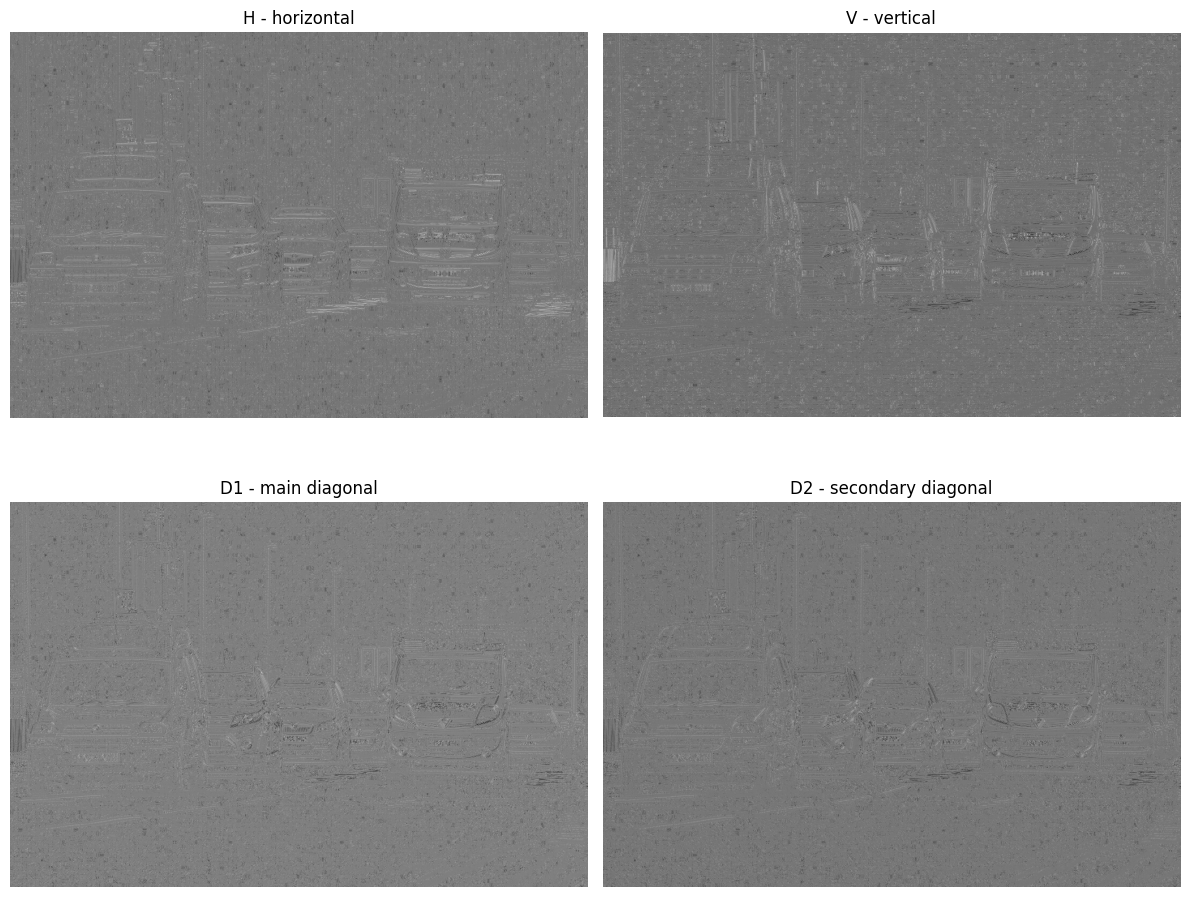

In [6]:
# ============================================================
# 6. Pairwise products in four directions
# ============================================================

def pairwise_products(mscn):
    # Computes pairwise products in four orientations.
    H = mscn[:, :-1] * mscn[:, 1:]
    V = mscn[:-1, :] * mscn[1:, :]
    D1 = mscn[:-1, :-1] * mscn[1:, 1:]
    D2 = mscn[:-1, 1:] * mscn[1:, :-1]
    return H, V, D1, D2

H_prod, V_prod, D1_prod, D2_prod = pairwise_products(mscn)

products = {
    "H - horizontal": H_prod,
    "V - vertical": V_prod,
    "D1 - main diagonal": D1_prod,
    "D2 - secondary diagonal": D2_prod
}

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for ax, (name, product) in zip(axs, products.items()):
    ax.imshow(product, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Fit AGGD features to pairwise products

For each product distribution, BRISQUE estimates parameters from an Asymmetric Generalized Gaussian Distribution (AGGD).  
For each orientation, four features are extracted:

1. Shape parameter.
2. Mean parameter.
3. Left variance.
4. Right variance.

Since there are four orientations, this produces:

\[
4 \text{ orientations} \times 4 \text{ features} = 16 \text{ features}
\]

Together with the two GGD features from MSCN coefficients:

\[
2 + 16 = 18 \text{ features per scale}
\]

,Orientation,AGGD alpha,Mean parameter,Left variance,Right variance
0,H - horizontal,0.642,0.042920,0.040443,0.073457
1,V - vertical,0.650,0.051827,0.034530,0.072818
2,D1 - main diagonal,0.703,-0.024923,0.054209,0.037482
3,D2 - secondary diagonal,0.702,-0.024195,0.053987,0.037734


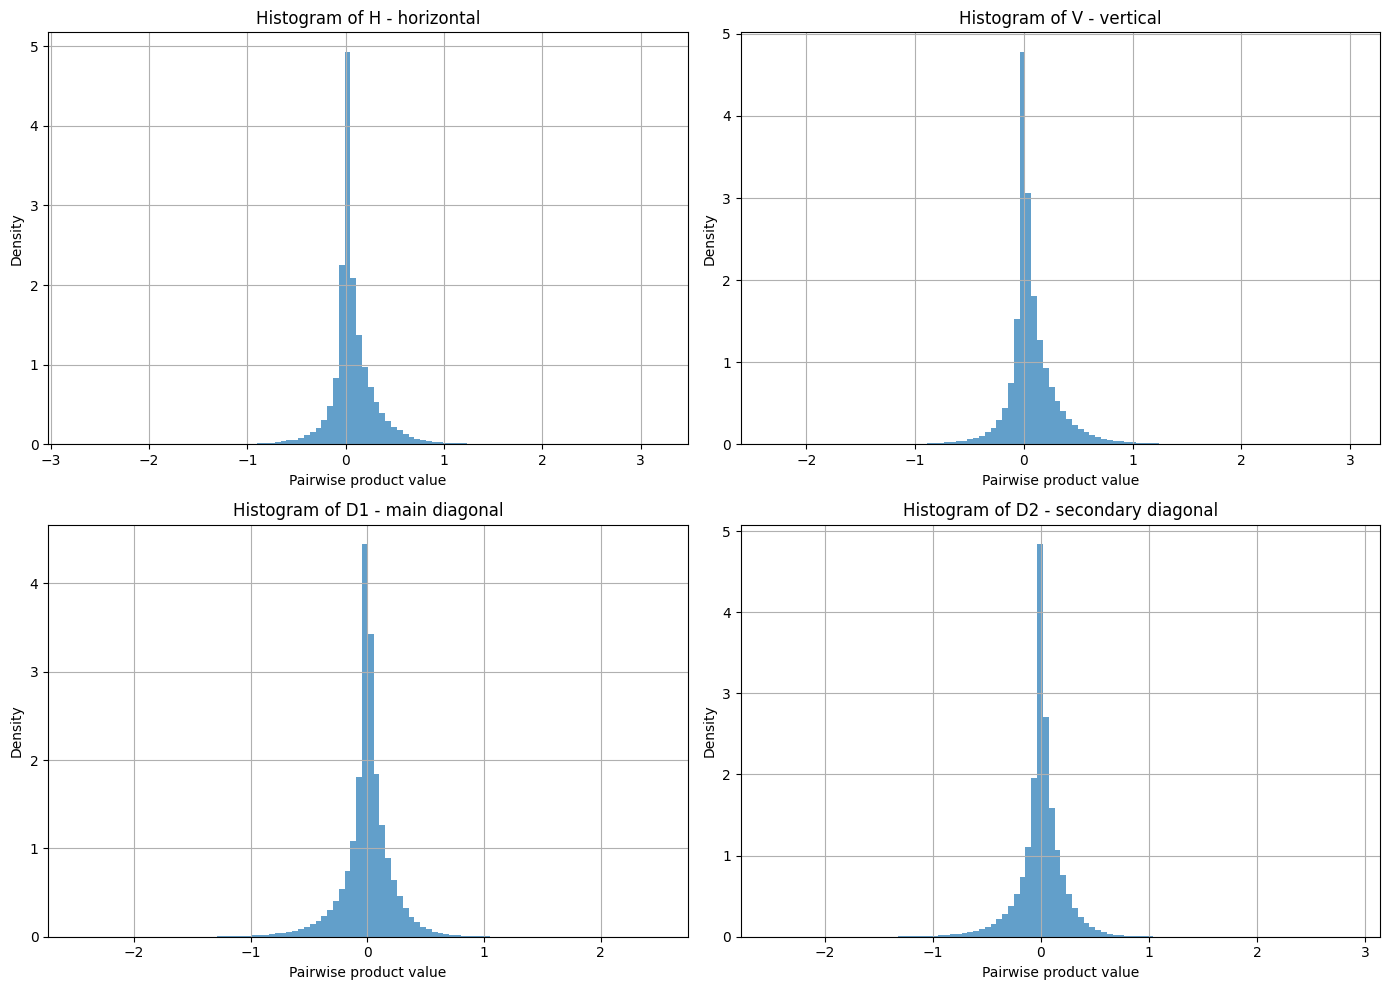

In [7]:
# ============================================================
# 7. Estimate AGGD parameters
# ============================================================

def estimate_aggd_parameters(vec):
    # Estimates AGGD parameters for a vector of pairwise products.
    # Returns: alpha, mean_param, left_variance, right_variance
    vec = vec.flatten()
    vec = vec[np.isfinite(vec)]

    left_data = vec[vec < 0]
    right_data = vec[vec > 0]

    left_std = np.sqrt(np.mean(left_data ** 2)) if len(left_data) > 0 else 0
    right_std = np.sqrt(np.mean(right_data ** 2)) if len(right_data) > 0 else 0

    if right_std == 0:
        right_std = 1e-6

    gamma_hat = left_std / right_std

    r_hat = (np.mean(np.abs(vec)) ** 2) / np.mean(vec ** 2)
    r_hat_norm = (r_hat * (gamma_hat ** 3 + 1) * (gamma_hat + 1)) / ((gamma_hat ** 2 + 1) ** 2)

    gammas = np.arange(0.2, 10, 0.001)
    r_gam = (gamma(2/gammas) ** 2) / (gamma(1/gammas) * gamma(3/gammas))

    alpha = gammas[np.argmin(np.abs(r_gam - r_hat_norm))]

    beta_l = left_std * np.sqrt(gamma(1/alpha) / gamma(3/alpha))
    beta_r = right_std * np.sqrt(gamma(1/alpha) / gamma(3/alpha))

    mean_param = (beta_r - beta_l) * (gamma(2/alpha) / gamma(1/alpha))

    left_variance = left_std ** 2
    right_variance = right_std ** 2

    return alpha, mean_param, left_variance, right_variance

aggd_rows = []

for name, product in products.items():
    alpha, mean_param, left_var, right_var = estimate_aggd_parameters(product)
    aggd_rows.append({
        "Orientation": name,
        "AGGD alpha": alpha,
        "Mean parameter": mean_param,
        "Left variance": left_var,
        "Right variance": right_var
    })

aggd_df = pd.DataFrame(aggd_rows)
display(aggd_df)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for ax, (name, product) in zip(axs, products.items()):
    vals = product.flatten()
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals > -5) & (vals < 5)]
    ax.hist(vals, bins=100, density=True, alpha=0.7)
    ax.set_title(f"Histogram of {name}")
    ax.set_xlabel("Pairwise product value")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## 8. Extract 18 BRISQUE features from one scale

At one scale:

- 2 features are extracted from the MSCN coefficient distribution.
- 16 features are extracted from the pairwise product distributions.

Therefore:

\[
2 + 16 = 18
\]

Then the process is repeated at a second reduced scale, resulting in:

\[
18 \times 2 = 36 \text{ BRISQUE features}
\]

In [8]:
# ============================================================
# 8. Extract BRISQUE-like features at one scale
# ============================================================

def brisque_features_one_scale(image):
    # Extracts 18 BRISQUE-like statistical features from one image scale.
    mscn, _, _ = compute_mscn_coefficients(image)

    features = []

    # 2 GGD features from MSCN
    alpha, sigma_sq = estimate_ggd_parameters(mscn)
    features.extend([alpha, sigma_sq])

    # 16 AGGD features from pairwise products
    H, V, D1, D2 = pairwise_products(mscn)
    for product in [H, V, D1, D2]:
        alpha, mean_param, left_var, right_var = estimate_aggd_parameters(product)
        features.extend([alpha, mean_param, left_var, right_var])

    return np.array(features), mscn

features_scale_1, mscn_scale_1 = brisque_features_one_scale(gray)

feature_names_one_scale = [
    "MSCN alpha", "MSCN variance",
    "H alpha", "H mean", "H left variance", "H right variance",
    "V alpha", "V mean", "V left variance", "V right variance",
    "D1 alpha", "D1 mean", "D1 left variance", "D1 right variance",
    "D2 alpha", "D2 mean", "D2 left variance", "D2 right variance"
]

df_scale_1 = pd.DataFrame({
    "Feature": feature_names_one_scale,
    "Value": features_scale_1
})

display(df_scale_1)

,Feature,Value
0,MSCN alpha,2.028000
1,MSCN variance,0.207192
2,H alpha,0.642000
3,H mean,0.042920
4,H left variance,0.040443
5,H right variance,0.073457
6,V alpha,0.650000
7,V mean,0.051827
8,V left variance,0.034530
9,V right variance,0.072818


## 9. Repeat the process at two scales

BRISQUE computes the same 18 features at the original scale and at a second reduced scale.  
The second scale is obtained by resizing the image to half of its original width and height.

,Feature index,Feature name,Value
0,1,Scale 1 - MSCN alpha,2.028000
1,2,Scale 1 - MSCN variance,0.207192
2,3,Scale 1 - H alpha,0.642000
3,4,Scale 1 - H mean,0.042920
4,5,Scale 1 - H left variance,0.040443
5,6,Scale 1 - H right variance,0.073457
6,7,Scale 1 - V alpha,0.650000
7,8,Scale 1 - V mean,0.051827
8,9,Scale 1 - V left variance,0.034530
9,10,Scale 1 - V right variance,0.072818


Feature vector length: 36


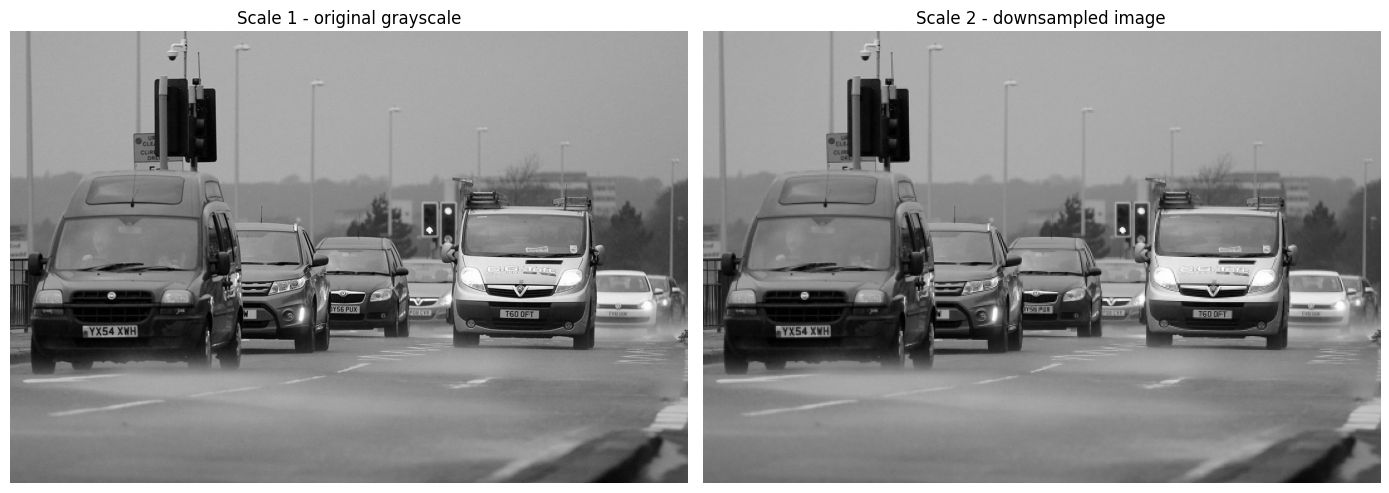

In [9]:
# ============================================================
# 9. Two-scale BRISQUE feature extraction
# ============================================================

# Scale 1: original grayscale image
features_scale_1, _ = brisque_features_one_scale(gray)

# Scale 2: image downsampled by factor of 2
gray_scale_2 = cv2.resize(
    gray,
    (gray.shape[1] // 2, gray.shape[0] // 2),
    interpolation=cv2.INTER_AREA
)

features_scale_2, mscn_scale_2 = brisque_features_one_scale(gray_scale_2)

# Final 36-dimensional feature vector
features_36 = np.concatenate([features_scale_1, features_scale_2])

feature_names_36 = [f"Scale 1 - {name}" for name in feature_names_one_scale] + \
                   [f"Scale 2 - {name}" for name in feature_names_one_scale]

df_features_36 = pd.DataFrame({
    "Feature index": np.arange(1, 37),
    "Feature name": feature_names_36,
    "Value": features_36
})

display(df_features_36)

print("Feature vector length:", len(features_36))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].imshow(gray, cmap="gray")
axs[0].set_title("Scale 1 - original grayscale")
axs[0].axis("off")

axs[1].imshow(gray_scale_2, cmap="gray")
axs[1].set_title("Scale 2 - downsampled image")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## 10. Compute the final BRISQUE score

The 36 statistical features explain how BRISQUE represents image quality.  
However, the final score requires a pretrained regression model.

In this notebook, the final BRISQUE score is computed using OpenCV's pretrained BRISQUE model and range files from the OpenCV contrib repository.

In [10]:
# ============================================================
# 10. Download OpenCV BRISQUE model and compute final score
# ============================================================

model_url = "https://raw.githubusercontent.com/opencv/opencv_contrib/4.x/modules/quality/samples/brisque_model_live.yml"
range_url = "https://raw.githubusercontent.com/opencv/opencv_contrib/4.x/modules/quality/samples/brisque_range_live.yml"

model_path = "brisque_model_live.yml"
range_path = "brisque_range_live.yml"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

if not os.path.exists(range_path):
    urllib.request.urlretrieve(range_url, range_path)

print("Model file downloaded:", os.path.exists(model_path))
print("Range file downloaded:", os.path.exists(range_path))

if not hasattr(cv2, "quality"):
    raise RuntimeError(
        "cv2.quality is not available. Runtime may need to be restarted after installing opencv-contrib-python-headless."
    )

# Compute BRISQUE score
try:
    score = cv2.quality.QualityBRISQUE_compute(img_bgr, model_path, range_path)
    brisque_score = float(score[0])
except Exception as e:
    print("Direct compute failed, trying object-based API.")
    brisque_model = cv2.quality.QualityBRISQUE_create(model_path, range_path)
    score = brisque_model.compute(img_bgr)
    brisque_score = float(score[0])

print("Final BRISQUE score:", brisque_score)

Model file downloaded: True
Range file downloaded: True
Final BRISQUE score: 19.492374420166016


## 11. Visual interpretation of the BRISQUE score

A lower BRISQUE score usually indicates better perceptual image quality.  
A higher score indicates more perceptual degradation.

The approximate interpretation is:

- **0 to 20:** very good quality.
- **20 to 40:** good or acceptable quality.
- **40 to 60:** moderate degradation.
- **60 to 100:** strong degradation.

This interpretation is approximate and depends on the dataset and image conditions.

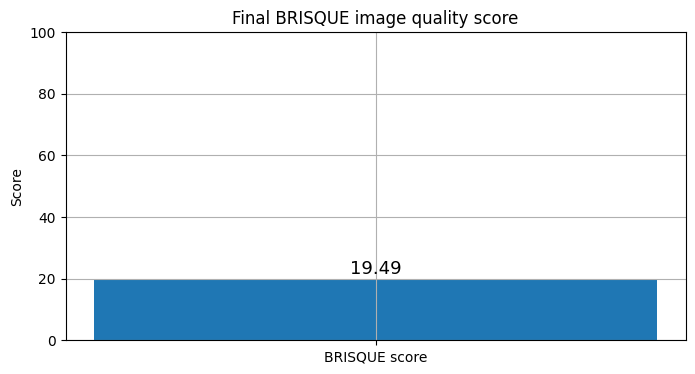

Interpretation: Very good perceptual quality


In [11]:
# ============================================================
# 11. Plot final BRISQUE score
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(["BRISQUE score"], [brisque_score])
plt.ylim(0, 100)
plt.ylabel("Score")
plt.title("Final BRISQUE image quality score")

for i, v in enumerate([brisque_score]):
    plt.text(i, v + 2, f"{v:.2f}", ha="center", fontsize=13)

plt.show()

if brisque_score < 20:
    interpretation = "Very good perceptual quality"
elif brisque_score < 40:
    interpretation = "Good or acceptable perceptual quality"
elif brisque_score < 60:
    interpretation = "Moderate perceptual degradation"
else:
    interpretation = "Strong perceptual degradation"

print("Interpretation:", interpretation)

## 12. Summary of the complete BRISQUE workflow

The complete BRISQUE process can be summarized as:

\[
Image \rightarrow Grayscale \rightarrow MSCN \rightarrow GGD + AGGD \rightarrow 36 features \rightarrow Regression model \rightarrow BRISQUE score
\]

In simple terms:

1. The image is normalized using MSCN coefficients.
2. The distribution of MSCN coefficients is modeled using GGD.
3. Relationships between neighboring coefficients are modeled using AGGD.
4. The features are extracted at two scales.
5. The final 36 features are passed to a trained model.
6. The model outputs the BRISQUE quality score.